# Data Cleaning and Preprocessing - VentureSurvive


In [17]:
# Imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path to the raw file
DATA_PATH = "../data/startups_raw.csv"
print("Setup complete. Ready to load data.")


Setup complete. Ready to load data.


## 1. Data Loading


In [18]:
# Load the dataset

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

# Display first few rows
display(df_raw.head())


Dataset loaded successfully!
Shape: 66,368 rows × 14 columns

Column names:
['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


Filtered dataset shape: (13334, 17)
Rows kept: 13,334 out of 66,368 (20.1%)

Target variable distribution (success):


/var/folders/41/yj4cj30d2rlfs2blhkbw_08m0000gn/T/ipykernel_1336/3377788558.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_model.loc[mask_valid, "survived_5y"] = df_model.loc[mask_valid, "years_alive"] >= 5


,Label,Count,Percentage
0,Success (years_alive>=5 or acquired/ipo),7804,58.527074
1,Failure (otherwise),5530,41.472926


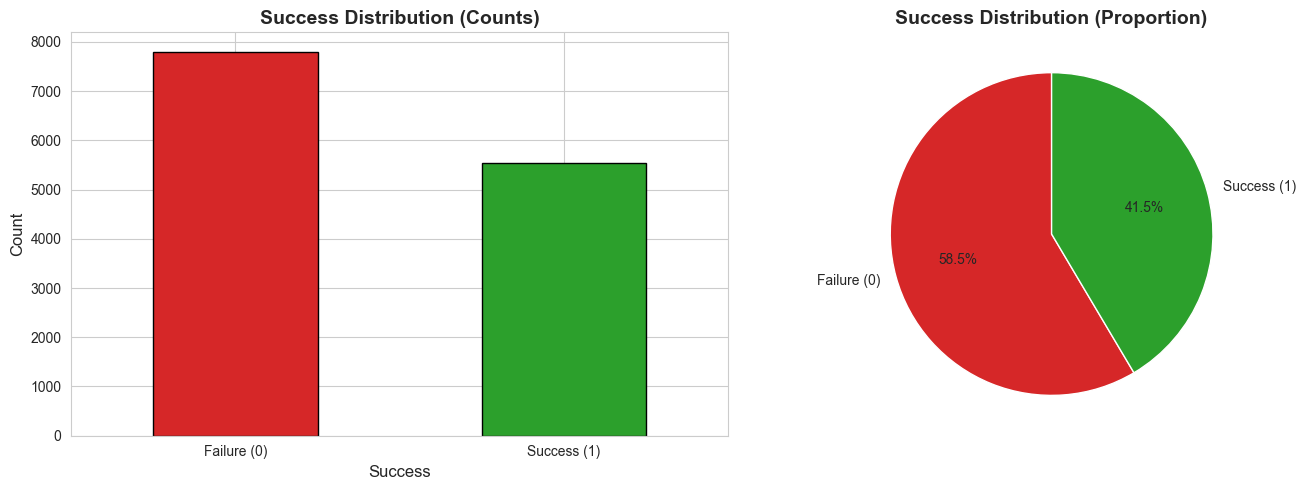

In [19]:
# Keep only the statuses that are relevant for the modeling
status_keep = ["acquired", "ipo", "closed"]
df_model = df_raw[df_raw["status"].isin(status_keep)].copy()

# Convert date columns to datetime format (if present)
for col in ["founded_at", "first_funding_at", "last_funding_at"]:
    if col in df_model.columns:
        df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

# Initialize target-related columns
df_model["years_alive"] = np.nan
df_model["survived_5y"] = np.nan

# Approximate last observed date using the latest available funding date
if {"founded_at", "first_funding_at", "last_funding_at"}.issubset(df_model.columns):
    end_date = df_model["last_funding_at"].fillna(df_model["first_funding_at"])

    # Compute years_alive where both founded_at and end_date are available
    mask_valid = df_model["founded_at"].notna() & end_date.notna()
    df_model.loc[mask_valid, "years_alive"] = (
        (end_date[mask_valid] - df_model.loc[mask_valid, "founded_at"]).dt.days / 365.25
    )

    # survived_5y: True if years_alive >= 5
    df_model.loc[mask_valid, "survived_5y"] = df_model.loc[mask_valid, "years_alive"] >= 5

# Define the final target `success` consistently with Notebook 1
exit_mask = df_model["status"].isin(["acquired", "ipo"])
long_lived_mask = df_model["years_alive"].ge(5)

success_series = exit_mask | long_lived_mask.fillna(False)
df_model["success"] = success_series.astype(int)

# Optionally drop rows where success could not be computed (should be none here,
# but this makes the modeling dataset explicit and safe)
before_rows = df_model.shape[0]
df_model = df_model[df_model["success"].notna()].copy()
after_rows = df_model.shape[0]

if after_rows < before_rows:
    print(f"Dropped {before_rows - after_rows} rows with undefined success.")

print(f"Filtered dataset shape: {df_model.shape}")
print(f"Rows kept: {df_model.shape[0]:,} out of {df_raw.shape[0]:,} "
      f"({df_model.shape[0]/df_raw.shape[0]*100:.1f}%)")

print("\n" + "=" * 60)
print("Target variable distribution (success):")
print("=" * 60)

success_counts = df_model["success"].value_counts()
success_pct = df_model["success"].value_counts(normalize=True) * 100

success_df = pd.DataFrame({
    "Label": ["Success (years_alive>=5 or acquired/ipo)", "Failure (otherwise)"],
    "Count": [success_counts.get(1, 0), success_counts.get(0, 0)],
    "Percentage": [success_pct.get(1, 0.0), success_pct.get(0, 0.0)],
})
display(success_df)

# Plot the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot (counts)
success_counts.plot(kind='bar', ax=axes[0],
                    color=['#d62728', '#2ca02c'], edgecolor='black')
axes[0].set_title("Success Distribution (Counts)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Success", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(['Failure (0)', 'Success (1)'], rotation=0)

# Pie chart (percentage)
axes[1].pie(
    success_counts,
    labels=['Failure (0)', 'Success (1)'],
    autopct='%1.1f%%',
    colors=['#d62728', '#2ca02c'],
    startangle=90
)
axes[1].set_title("Success Distribution (Proportion)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Missing Values Analysis


In [20]:
# Convert date columns first

for col in ["founded_at", "first_funding_at", "last_funding_at"]:
    if col in df_model.columns:
        df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

print("Date columns converted to datetime format.")


Date columns converted to datetime format.


Missing Values Summary:


,Missing_Count,Missing_Percentage
founded_at,3734,28.003600
years_alive,3734,28.003600
survived_5y,3734,28.003600
state_code,2209,16.566672
region,2152,16.139193
city,2152,16.139193
country_code,1991,14.931753
homepage_url,1217,9.127044
category_list,1086,8.144593
first_funding_at,2,0.014999


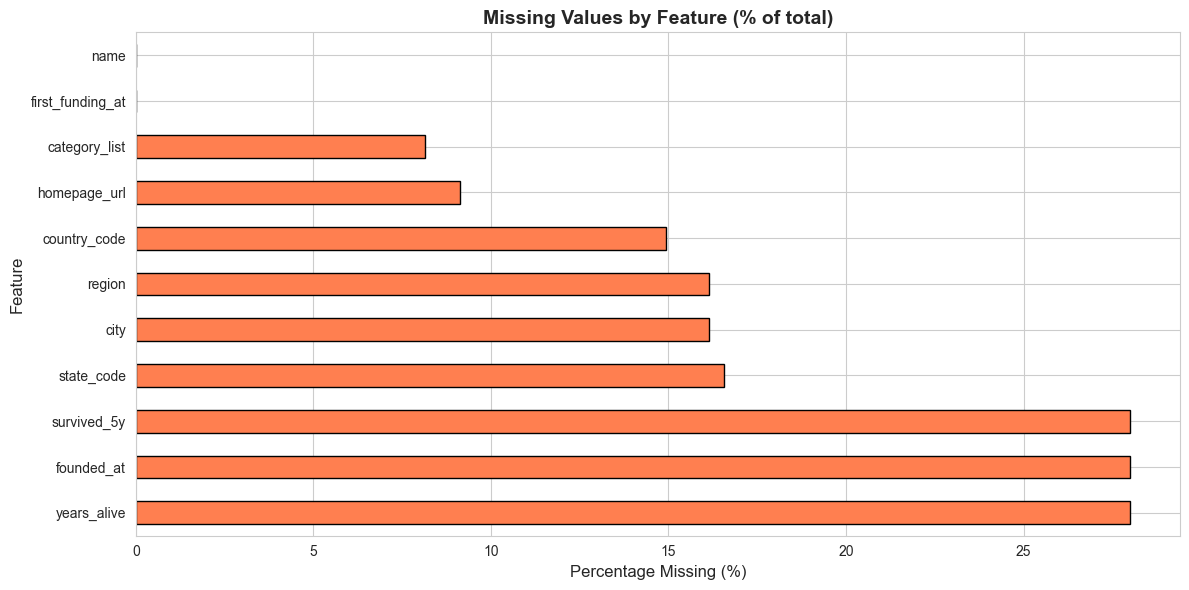

In [21]:
# Missing values analysis

missing_counts = df_model.isna().sum()
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percentage": missing_pct
}).sort_values("Missing_Percentage", ascending=False)

print("Missing Values Summary:")
print("=" * 60)
display(missing_df[missing_df["Missing_Count"] > 0])

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct_filtered = missing_pct[missing_pct > 0]
missing_pct_filtered.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title("Missing Values by Feature (% of total)", fontsize=14, fontweight='bold')
ax.set_xlabel("Percentage Missing (%)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Feature Engineering & Analysis


In [22]:
# Create preliminary features

# Time-based features
df_model['age_at_first_funding'] = (df_model["first_funding_at"] - df_model["founded_at"]).dt.days
df_model['time_between_first_last'] = (df_model["last_funding_at"] - df_model["first_funding_at"]).dt.days

# Funding features
df_model['funding_numeric'] = pd.to_numeric(df_model["funding_total_usd"], errors="coerce")
df_model['log_funding_total'] = np.log1p(df_model['funding_numeric'])

# Geographic features
df_model['is_us'] = (df_model['country_code'] == 'USA').astype(int)
df_model['has_country'] = df_model['country_code'].notna().astype(int)

print("Preliminary features created:")
print("- age_at_first_funding: days between founding and first funding")
print("- time_between_first_last: days between first and last funding")
print("- log_funding_total: log-transformed total funding")
print("- is_us: binary indicator for US-based startups")
print("- has_country: binary indicator for country information availability")

print(f"\nDataset shape after feature engineering: {df_model.shape}")


Preliminary features created:
- age_at_first_funding: days between founding and first funding
- time_between_first_last: days between first and last funding
- log_funding_total: log-transformed total funding
- is_us: binary indicator for US-based startups
- has_country: binary indicator for country information availability

Dataset shape after feature engineering: (13334, 23)


Summary Statistics for Numeric Features:


,funding_rounds,age_at_first_funding,time_between_first_last,funding_numeric,log_funding_total
count,13334.000000,9598.000000,13332.000000,1.114300e+04,11143.000000
mean,1.859832,1631.430923,441.487399,3.580863e+07,15.192404
std,1.515366,3788.444433,869.874163,3.687556e+08,2.387477
min,1.000000,-9518.000000,0.000000,2.000000e+00,1.098612
25%,1.000000,123.000000,0.000000,1.000000e+06,13.815512
50%,1.000000,550.000000,0.000000,5.800000e+06,15.573369
75%,2.000000,1726.750000,591.250000,2.200000e+07,16.906553
max,18.000000,75589.000000,33628.000000,3.007950e+10,24.127110


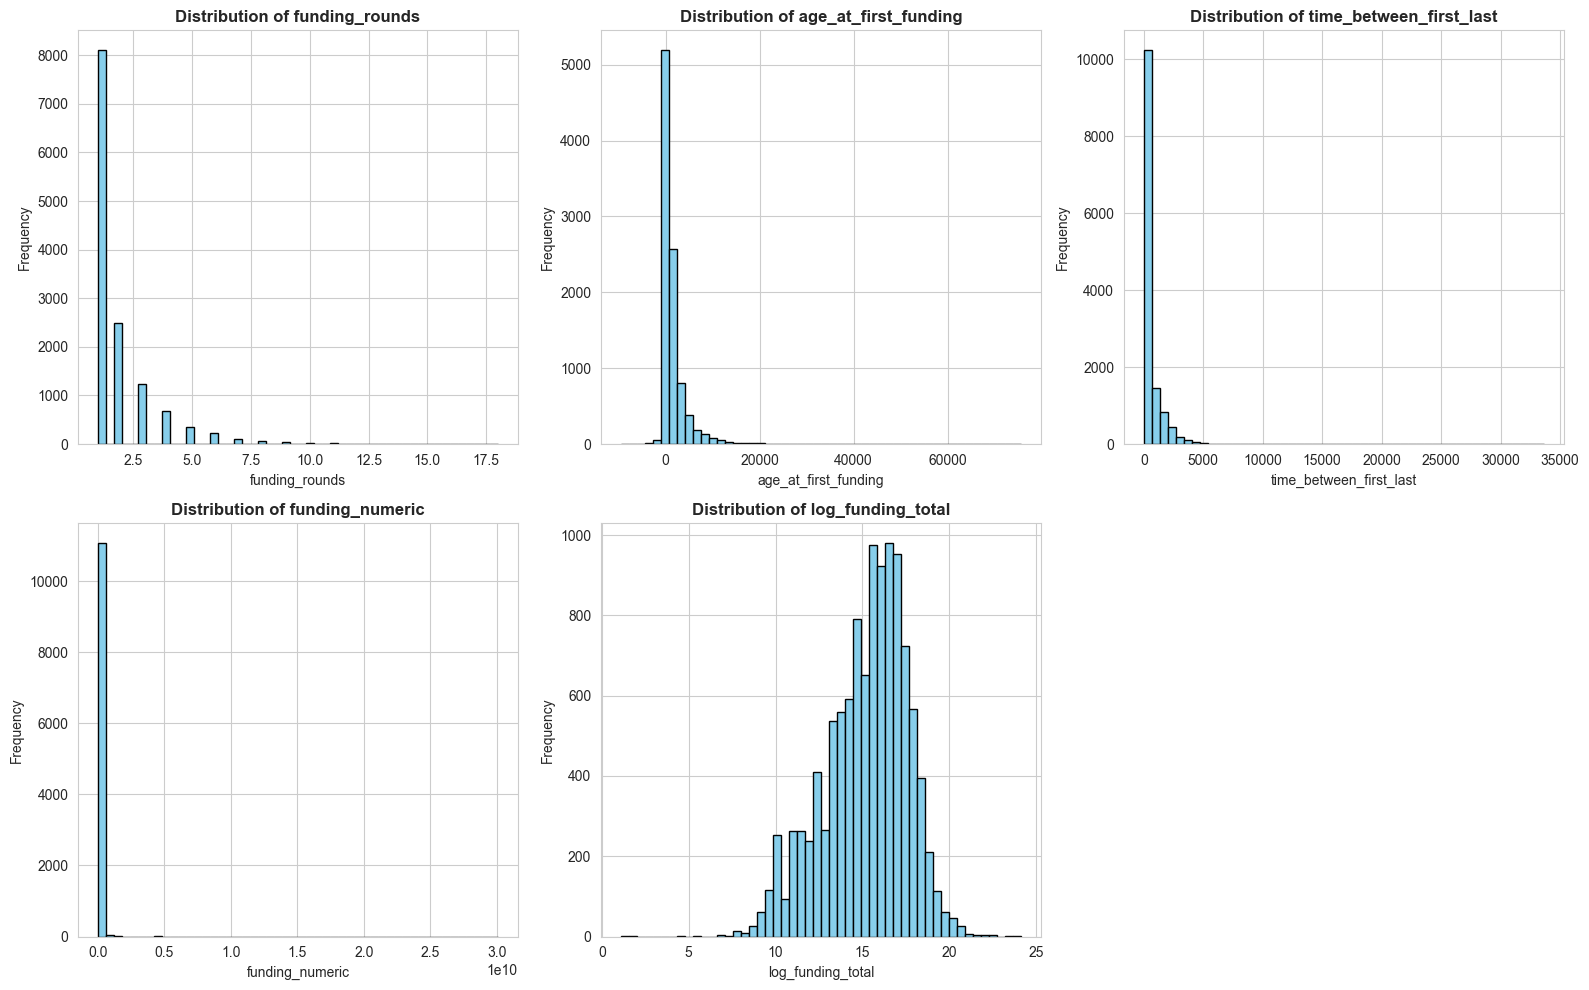

In [23]:
# Analyze numeric features

numeric_features = ['funding_rounds', 'age_at_first_funding', 'time_between_first_last', 
                    'funding_numeric', 'log_funding_total']

print("Summary Statistics for Numeric Features:")
print("=" * 60)
display(df_model[numeric_features].describe())

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        df_model[col].dropna().hist(bins=50, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)

# Remove extra subplot
if len(numeric_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [24]:
# Save cleaned dataset for modeling / EDA in another notebook

df_model.to_csv("../data/processed/startups_clean.csv", index=False)
print("Cleaned dataset saved to ../data/processed/startups_clean.csv")


Cleaned dataset saved to ../data/processed/startups_clean.csv
